# W2 – Data Exploration & Baseline Model
**Deadline:** 17/05/2026

This notebook covers:
1. DermaMNIST EDA (class distribution, pixel statistics, sample visualization)
2. Task split verification
3. First baseline model: Naive Fine-tuning
4. Core metrics: per-task accuracy after sequential training


In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from torchvision import transforms
print(f'PyTorch {torch.__version__}')


PyTorch 2.10.0+cpu


## 1. Dataset Loading & EDA


In [6]:
from medmnist import DermaMNIST
from src.utils.data import CLASS_NAMES, TASK_CLASSES

transform = transforms.Compose([transforms.ToTensor()])
train_ds = DermaMNIST(split='train', transform=transform, download=True, root='../data')
val_ds   = DermaMNIST(split='val',   transform=transform, download=True, root='../data')
test_ds  = DermaMNIST(split='test',  transform=transform, download=True, root='../data')

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Image size: {train_ds[0][0].shape}')
print(f'Classes: {CLASS_NAMES}')


Train: 7007 | Val: 1003 | Test: 2005
Image size: torch.Size([3, 28, 28])
Classes: ['Melanocytic nevi', 'Melanoma', 'Benign keratosis', 'Basal cell carcinoma', 'Actinic keratoses', 'Vascular lesions', 'Dermatofibroma']


C:\Users\LENOVO T14S\AppData\Local\Temp\ipykernel_18780\3423481787.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  train_labels = [int(train_ds[i][1]) for i in range(len(train_ds))]
C:\Users\LENOVO T14S\AppData\Local\Temp\ipykernel_18780\3423481787.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  test_labels  = [int(test_ds[i][1])  for i in range(len(test_ds))]


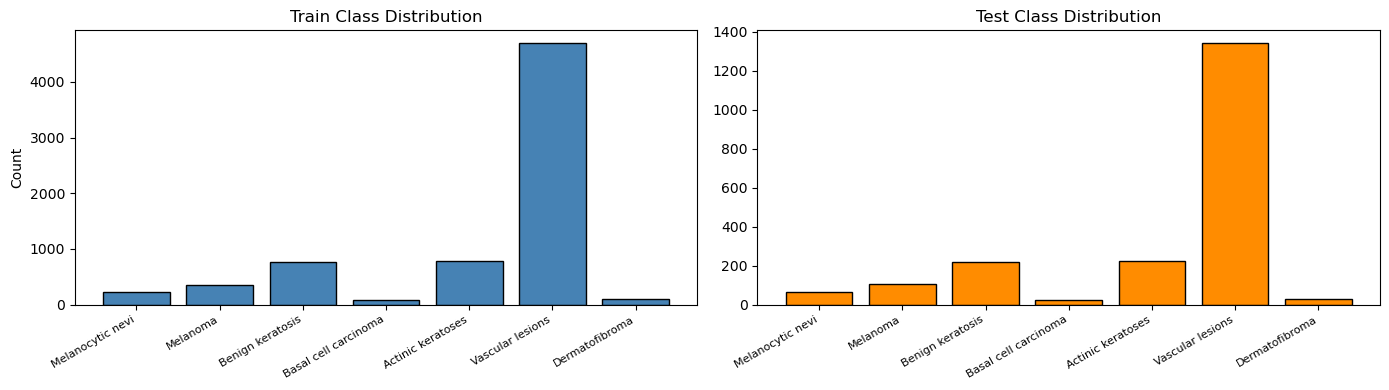

Class imbalance ratio (max/min): 58.6625


In [7]:
# Class distribution
train_labels = [int(train_ds[i][1]) for i in range(len(train_ds))]
test_labels  = [int(test_ds[i][1])  for i in range(len(test_ds))]
train_counts = np.bincount(train_labels, minlength=7)
test_counts  = np.bincount(test_labels,  minlength=7)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(7), train_counts, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(7)); axes[0].set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
axes[0].set_title('Train Class Distribution'); axes[0].set_ylabel('Count')
axes[1].bar(range(7), test_counts, color='darkorange', edgecolor='black')
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
axes[1].set_title('Test Class Distribution')
plt.tight_layout(); plt.savefig('../results/w2_class_distribution.png', dpi=120, bbox_inches='tight'); plt.show()
print('Class imbalance ratio (max/min):', train_counts.max()/train_counts.min())


In [8]:
# Pixel statistics per channel
loader = torch.utils.data.DataLoader(train_ds, batch_size=512, shuffle=False, num_workers=2)
mean = torch.zeros(3); std = torch.zeros(3); n = 0
for imgs, _ in loader:
    mean += imgs.mean(dim=[0,2,3]) * imgs.size(0)
    std  += imgs.std(dim=[0,2,3])  * imgs.size(0)
    n += imgs.size(0)
mean /= n; std /= n
print(f'Channel mean: {mean.numpy().round(3)}')
print(f'Channel std:  {std.numpy().round(3)}')
print('(Used in TEST_TRANSFORM normalization)')


Channel mean: [0.763 0.538 0.561]
Channel std:  [0.137 0.154 0.169]
(Used in TEST_TRANSFORM normalization)


C:\Users\LENOVO T14S\AppData\Local\Temp\ipykernel_18780\1918569630.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lbl = int(lbl)


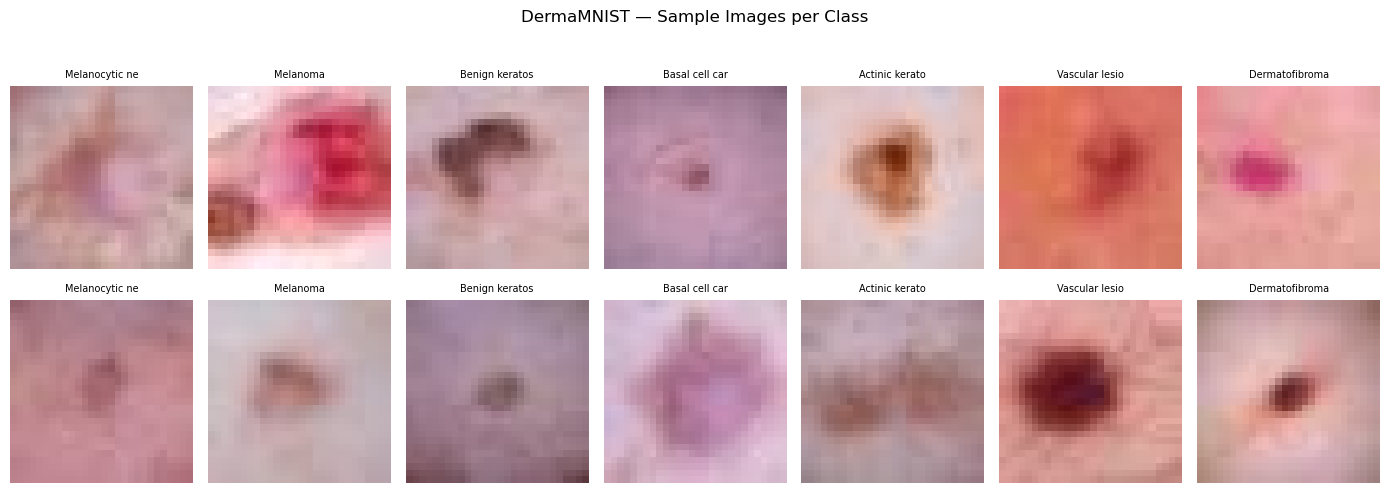

In [9]:
# Sample images per class
fig, axes = plt.subplots(2, 7, figsize=(14, 5))
shown1 = {i:False for i in range(7)}; shown2 = {i:False for i in range(7)}
for ds_split, shown, row in [(train_ds, shown1, 0), (test_ds, shown2, 1)]:
    for img, lbl in ds_split:
        lbl = int(lbl)
        if not shown[lbl]:
            ax = axes[row, lbl]
            ax.imshow(img.permute(1,2,0).numpy().clip(0,1))
            ax.set_title(CLASS_NAMES[lbl][:14], fontsize=7)
            ax.axis('off'); shown[lbl] = True
        if all(shown.values()): break
axes[0,0].set_ylabel('Train', fontsize=10)
axes[1,0].set_ylabel('Test',  fontsize=10)
plt.suptitle('DermaMNIST — Sample Images per Class', fontsize=12, y=1.02)
plt.tight_layout(); plt.savefig('../results/w2_sample_images.png', dpi=120, bbox_inches='tight'); plt.show()


In [10]:
# Task split verification
print('Task Split:')
for t, classes in enumerate(TASK_CLASSES):
    names = [CLASS_NAMES[c] for c in classes]
    n_train = sum(train_counts[c] for c in classes)
    n_test  = sum(test_counts[c]  for c in classes)
    print(f'  Task {t}: {names}  |  Train: {n_train}, Test: {n_test}')


Task Split:
  Task 0: ['Melanocytic nevi', 'Melanoma', 'Benign keratosis']  |  Train: 1356, Test: 389
  Task 1: ['Basal cell carcinoma', 'Actinic keratoses']  |  Train: 859, Test: 246
  Task 2: ['Vascular lesions', 'Dermatofibroma']  |  Train: 4792, Test: 1370


## 2. Baseline: Naive Fine-tuning


In [11]:
from src.models.cnn import build_model
from src.methods.naive import NaiveTrainer
from src.utils.data import get_all_tasks_dataloaders
from src.utils.metrics import evaluate, compute_cl_metrics

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 5  # Quick baseline — use 10+ for final results
BATCH_SIZE = 64

all_loaders = get_all_tasks_dataloaders(batch_size=BATCH_SIZE, data_root='../data')
all_train = [tl for tl,_ in all_loaders]
all_test  = [vl for _,vl in all_loaders]

model = build_model(num_classes=7, device=DEVICE)
trainer = NaiveTrainer(model=model, device=DEVICE)
T = len(TASK_CLASSES)
acc_matrix = np.zeros((T, T))

for task_id in range(T):
    print(f'\n--- Task {task_id}: {[CLASS_NAMES[c] for c in TASK_CLASSES[task_id]]}')
    trainer.fit(task_id=task_id, train_loader=all_train[task_id], num_epochs=EPOCHS)
    for eval_task in range(T):
        acc = evaluate(model, all_test[eval_task], device=DEVICE)
        acc_matrix[task_id, eval_task] = acc
        if eval_task <= task_id:
            print(f'  Acc Task {eval_task}: {acc*100:.1f}%')



--- Task 0: ['Melanocytic nevi', 'Melanoma', 'Benign keratosis']
  [Task 0] Epoch 01/5  Loss: 1.0645
  [Task 0] Epoch 02/5  Loss: 0.9146
  [Task 0] Epoch 03/5  Loss: 0.8805
  [Task 0] Epoch 04/5  Loss: 0.8447
  [Task 0] Epoch 05/5  Loss: 0.7768
  Acc Task 0: 69.9%

--- Task 1: ['Basal cell carcinoma', 'Actinic keratoses']
  [Task 1] Epoch 01/5  Loss: 0.4227
  [Task 1] Epoch 02/5  Loss: 0.2276
  [Task 1] Epoch 03/5  Loss: 0.1946
  [Task 1] Epoch 04/5  Loss: 0.1923
  [Task 1] Epoch 05/5  Loss: 0.1911
  Acc Task 0: 24.4%
  Acc Task 1: 93.5%

--- Task 2: ['Vascular lesions', 'Dermatofibroma']
  [Task 2] Epoch 01/5  Loss: 0.2610
  [Task 2] Epoch 02/5  Loss: 0.0826
  [Task 2] Epoch 03/5  Loss: 0.0626
  [Task 2] Epoch 04/5  Loss: 0.0553
  [Task 2] Epoch 05/5  Loss: 0.0524
  Acc Task 0: 20.1%
  Acc Task 1: 15.0%
  Acc Task 2: 98.3%


Naive Fine-tuning Results:
  FAA:  44.5%
  BWT:  -64.2%  (negative = forgetting)


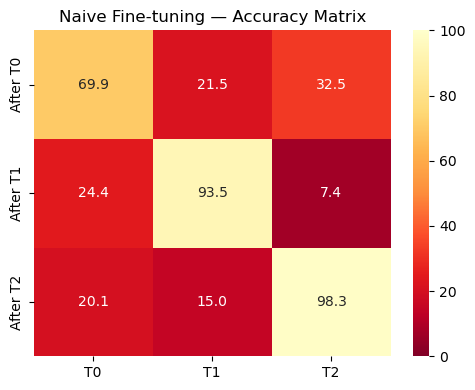

Diagonal = accuracy right after training that task (no forgetting yet)
Off-diagonal = forgetting on previous tasks


In [12]:
import seaborn as sns
metrics = compute_cl_metrics(acc_matrix)
print(f'Naive Fine-tuning Results:')
print(f'  FAA:  {metrics["faa"]*100:.1f}%')
print(f'  BWT:  {metrics["bwt"]*100:+.1f}%  (negative = forgetting)')

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(acc_matrix*100, annot=True, fmt='.1f', cmap='YlOrRd_r', vmin=0, vmax=100, ax=ax,
            xticklabels=[f'T{i}' for i in range(T)],
            yticklabels=[f'After T{i}' for i in range(T)])
ax.set_title('Naive Fine-tuning — Accuracy Matrix')
plt.tight_layout(); plt.savefig('../results/w2_naive_accuracy_matrix.png', dpi=120, bbox_inches='tight'); plt.show()
print('Diagonal = accuracy right after training that task (no forgetting yet)')
print('Off-diagonal = forgetting on previous tasks')


## 3. Summary & Risk Signals

**Expected finding**: Naive fine-tuning shows severe catastrophic forgetting — accuracy on Task 0 drops to near 0% after training on Tasks 1 and 2. This motivates the CL methods implemented in W3.

**Baseline metrics** (to be compared with CL methods):
- FAA ≈ low (dominated by forgetting)
- BWT ≈ very negative
